In [ ]:
!pip install wordcloud

---
## 1. Environment Setup & Spark Initialization <a id='1'></a>

In [1]:
# ============================================================
# 📌 SECTION 1 — IMPORTS & ENVIRONMENT SETUP
# ============================================================

import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from datetime import datetime

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, ArrayType,
    LongType, FloatType, BooleanType
)

# ── Plotting style ──────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
PALETTE = ['#6C5CE7', '#00B894', '#FDCB6E', '#E17055', '#74B9FF']
BOT_COLOR  = PALETTE[3]   # red  → bot
HUM_COLOR  = PALETTE[1]   # green → human

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [3]:
# ── Spark Session ────────────────────────────────────────────
# ⚠️  DO NOT CHANGE — Production cluster configuration
ip = "10.135.218.70"

spark = SparkSession.builder \
    .appName("BotDetectionEDA_Project") \
    .master(f"spark://{ip}:7077") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("="*55)
print("  ⚡  APACHE SPARK — CLUSTER SESSION ACTIVE")
print("="*55)
print(f"  Version  : {spark.version}")
print(f"  Master   : {spark.sparkContext.master}")
print(f"  App Name : {spark.sparkContext.appName}")
print("="*55)

26/04/21 17:47:30 WARN Utils: Your hostname, sachinsingh resolves to a loopback address: 127.0.1.1; using 10.135.218.70 instead (on interface wlo1)
26/04/21 17:47:30 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/21 17:47:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


  ⚡  APACHE SPARK — CLUSTER SESSION ACTIVE
  Version  : 3.5.8
  Master   : spark://10.135.218.70:7077
  App Name : BotDetectionEDA_Project


---
## 2. Data Loading — train.json + test.json <a id='2'></a>

In [5]:
# ============================================================
# 📌 SECTION 2 — DATA LOADING
# ============================================================
# ⚠️  DO NOT CHANGE — Production data paths
TRAIN_PATH = "file:///temp/Twibot-20/train.json"
TEST_PATH  = "file:///temp/Twibot-20/test.json"

print("="*55)
print("  📂  LOADING DATASET — DISTRIBUTED READ")
print("="*55)

# ── Load raw JSON via Spark (multiline JSON array) ──────────
# Each file is a JSON array of account objects
train_raw = spark.read.option("multiline", "true").json(TRAIN_PATH)
test_raw  = spark.read.option("multiline", "true").json(TEST_PATH)

# ── Tag splits then union ────────────────────────────────────
train_raw = train_raw.withColumn("split", F.lit("train"))
test_raw  = test_raw.withColumn("split",  F.lit("test"))
spark_df  = train_raw.unionByName(test_raw, allowMissingColumns=True)

total_records = spark_df.count()
print(f"  ✅ Total Records : {total_records:,}")
print(f"  ✅ Train         : {train_raw.count():,}")
print(f"  ✅ Test          : {test_raw.count():,}")
print("="*55)

# ── Flatten profile fields into top-level columns ───────────
spark_df = spark_df.select(
    F.col("ID").alias("id"),
    F.col("label"),                             # bot=1 / human=0 (present in train)
    F.col("split"),
    F.col("tweet"),                             # array<string>
    F.col("neighbor"),
    F.col("domain"),                            # array<string>
    # Profile fields
    F.col("profile.followers_count").cast("long").alias("followers"),
    F.col("profile.friends_count").cast("long").alias("friends"),
    F.col("profile.statuses_count").cast("long").alias("statuses"),
    F.col("profile.favourites_count").cast("long").alias("favourites"),
    F.col("profile.listed_count").cast("long").alias("listed"),
    F.col("profile.verified").alias("verified"),
    F.col("profile.default_profile").alias("default_profile"),
    F.col("profile.default_profile_image").alias("default_profile_image"),
    F.col("profile.geo_enabled").alias("geo_enabled"),
    F.col("profile.description").alias("description"),
    F.col("profile.location").alias("location"),
    F.col("profile.screen_name").alias("screen_name"),
    F.col("profile.name").alias("name"),
    F.col("profile.created_at").alias("created_at"),
)

print("\n🔍 Sample rows:")
spark_df.select("id","label","followers","friends","statuses","split").show(5)

  📂  LOADING DATASET — DISTRIBUTED READ


26/04/21 17:48:01 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


  ✅ Total Records : 9,461
  ✅ Train         : 8,278
  ✅ Test          : 1,183

🔍 Sample rows:


+-------------------+-----+---------+-------+--------+-----+
|                 id|label|followers|friends|statuses|split|
+-------------------+-----+---------+-------+--------+-----+
|           17461978|    0| 15349596|    692|    9798|train|
|1297437077403885568|    1|        0|     44|       0|train|
|           17685258|    0|   762839|    475|    5518|train|
|           15750898|    0|   327587|   4801|  192876|train|
|         1659167666|    1|    13324|    647|     103|train|
+-------------------+-----+---------+-------+--------+-----+
only showing top 5 rows



---
## 3. Label Distribution Analysis <a id='3'></a>


📊 Label Distribution (Train Set):


+-----+-----+
|label|count|
+-----+-----+
|    0| 3632|
|    1| 4646|
+-----+-----+



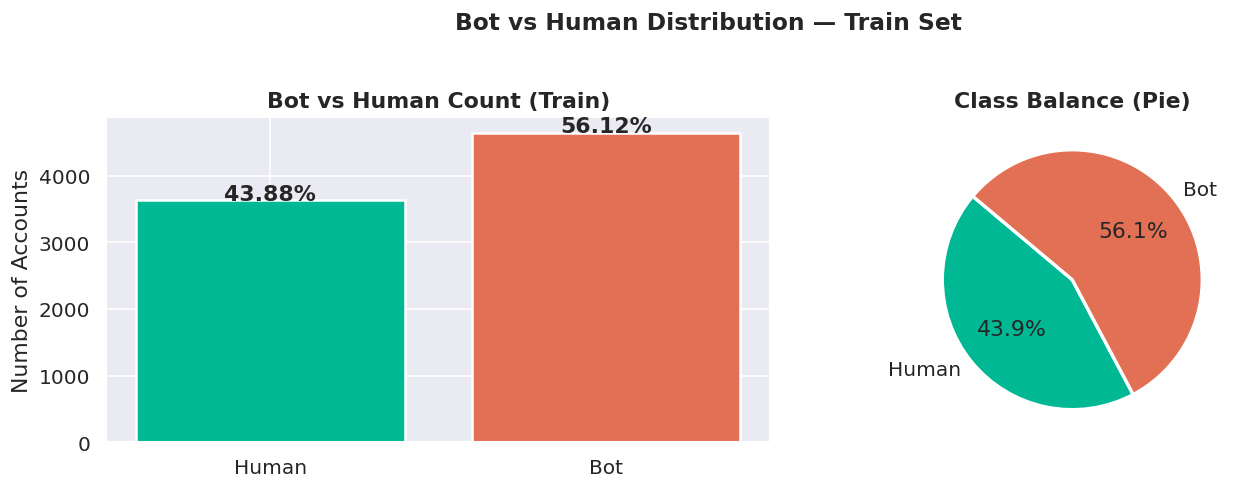

✅ Saved: label_distribution.png

📊 Train/Test Split Breakdown:


+-----+-----+
|split|count|
+-----+-----+
|train| 8278|
| test| 1183|
+-----+-----+



In [6]:
# ============================================================
# 📌 SECTION 3 — LABEL DISTRIBUTION
# ============================================================

# Train-only for label stats (test has no labels)
train_df = spark_df.filter(F.col("split") == "train")

print("\n📊 Label Distribution (Train Set):")
label_dist = train_df.groupBy("label").count().orderBy("label")
label_dist.show()

label_pd = label_dist.toPandas()
label_pd['name'] = label_pd['label'].map({'1': 'Bot', '0': 'Human',
                                           1: 'Bot',   0: 'Human'})
label_pd['pct']  = (label_pd['count'] / label_pd['count'].sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar
bars = axes[0].bar(label_pd['name'], label_pd['count'],
                   color=[HUM_COLOR, BOT_COLOR], edgecolor='white', linewidth=1.5)
axes[0].set_title("Bot vs Human Count (Train)", fontweight='bold')
axes[0].set_ylabel("Number of Accounts")
for bar, pct in zip(bars, label_pd['pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f"{pct}%", ha='center', fontweight='bold')

# Pie
axes[1].pie(label_pd['count'], labels=label_pd['name'],
            colors=[HUM_COLOR, BOT_COLOR], autopct='%1.1f%%',
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title("Class Balance (Pie)", fontweight='bold')

plt.suptitle("Bot vs Human Distribution — Train Set",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("label_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: label_distribution.png")

# Train vs Test split breakdown
print("\n📊 Train/Test Split Breakdown:")
spark_df.groupBy("split").count().show()

---
## 4. Profile Feature Analysis <a id='4'></a>


📐 Profile Numeric Statistics (Train):


+----------------+--------------+---------------+-----------------+-------------+
|followers_median|friends_median|statuses_median|favourites_median|listed_median|
+----------------+--------------+---------------+-----------------+-------------+
|            1933|           723|           3622|             1584|           13|
+----------------+--------------+---------------+-----------------+-------------+


📐 Profile Stats by Label (Bot=1 / Human=0):


+-----+------------------+-----------------+------------------+------------------+------------------+
|label|     avg_followers|      avg_friends|      avg_statuses|    avg_favourites|        avg_listed|
+-----+------------------+-----------------+------------------+------------------+------------------+
|    0|1443320.0327643172|8711.326266519824|29203.930892070486| 10918.50082599119|3277.2775330396476|
|    1| 23513.98837709858|4967.142272922944|15632.191562634524|15157.233534222987|118.61472234179939|
+-----+------------------+-----------------+------------------+------------------+------------------+



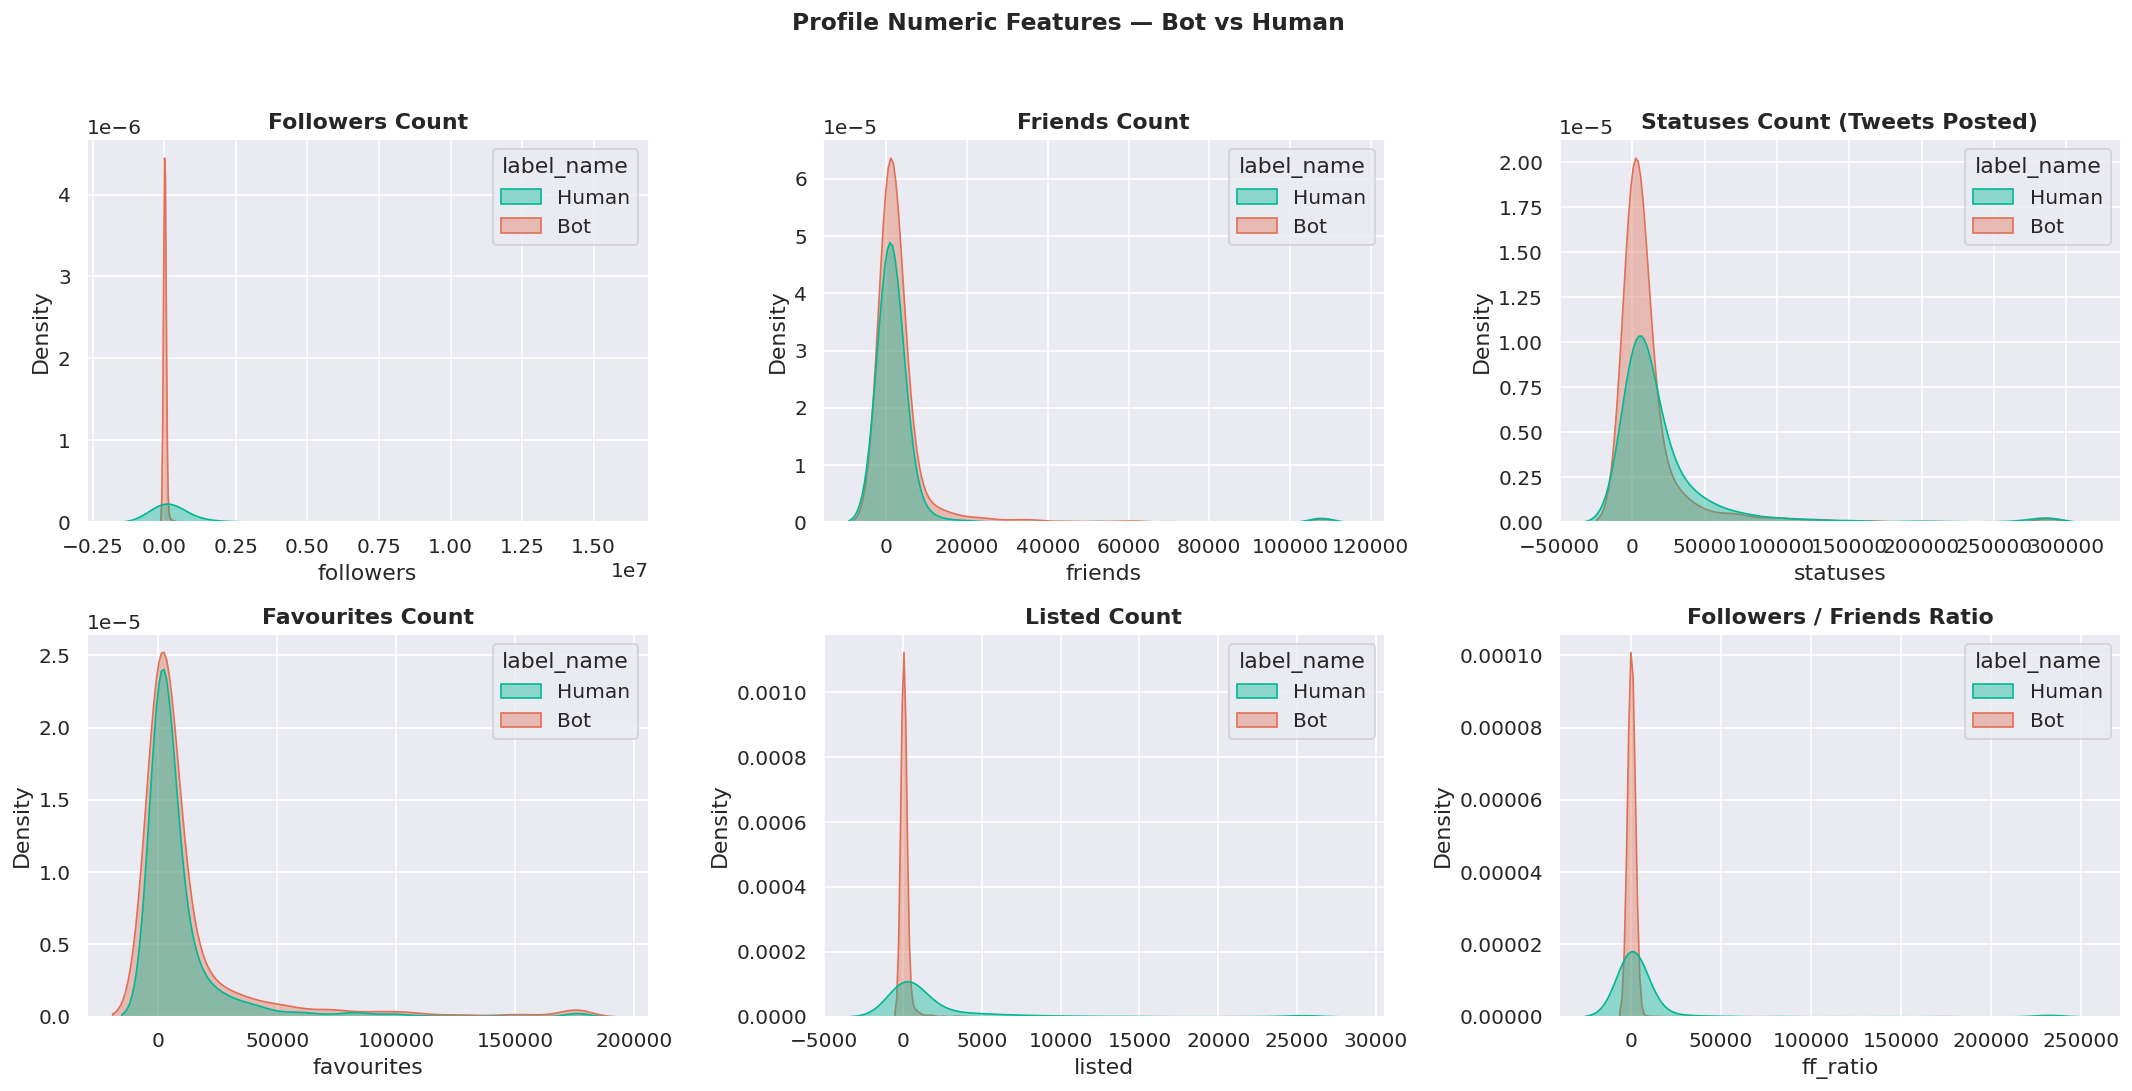

✅ Saved: profile_features.png


In [7]:
# ============================================================
# 📌 SECTION 4 — PROFILE FEATURE ANALYSIS
# ============================================================

# ── Numeric profile stats ────────────────────────────────────
num_cols = ['followers', 'friends', 'statuses', 'favourites', 'listed']

print("\n📐 Profile Numeric Statistics (Train):")
train_df.select(
    *[F.percentile_approx(c, 0.5).alias(f"{c}_median") for c in num_cols]
).show()

print("\n📐 Profile Stats by Label (Bot=1 / Human=0):")
train_df.groupBy("label").agg(
    F.avg("followers").alias("avg_followers"),
    F.avg("friends").alias("avg_friends"),
    F.avg("statuses").alias("avg_statuses"),
    F.avg("favourites").alias("avg_favourites"),
    F.avg("listed").alias("avg_listed"),
).orderBy("label").show()

# ── followers / friends ratio ────────────────────────────────
train_df = train_df.withColumn(
    "ff_ratio",
    F.when(F.col("friends") > 0,
           F.col("followers") / F.col("friends")).otherwise(F.col("followers").cast("float"))
)

# Sample to pandas for visualization
profile_pd = train_df.select(
    "label", "followers", "friends", "statuses", "favourites", "listed", "ff_ratio"
).sample(False, 0.5, seed=42).toPandas()

# Normalise label to string
profile_pd['label_name'] = profile_pd['label'].astype(str).map({'1':'Bot','0':'Human','1.0':'Bot','0.0':'Human'})

# Clip extreme outliers for plotting (99th pct)
for col in num_cols + ['ff_ratio']:
    cap = profile_pd[col].quantile(0.99)
    profile_pd[col] = profile_pd[col].clip(upper=cap)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
pal  = {'Bot': BOT_COLOR, 'Human': HUM_COLOR}

plot_pairs = [
    ('followers',  'Followers Count'),
    ('friends',    'Friends Count'),
    ('statuses',   'Statuses Count (Tweets Posted)'),
    ('favourites', 'Favourites Count'),
    ('listed',     'Listed Count'),
    ('ff_ratio',   'Followers / Friends Ratio'),
]

for ax, (col, title) in zip(axes, plot_pairs):
    sns.kdeplot(data=profile_pd, x=col, hue='label_name',
                fill=True, alpha=0.4, palette=pal, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle("Profile Numeric Features — Bot vs Human",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("profile_features.png", bbox_inches='tight')
plt.show()
print("✅ Saved: profile_features.png")


📝 Profile Description & Location Stats by Label:
+-----+-----------------+------------------+------------------+
|label|  avg_desc_length|     has_desc_rate|      has_loc_rate|
+-----+-----------------+------------------+------------------+
|    0|83.10600220264317|0.9052863436123348|0.7252202643171806|
|    1|82.99935428325442|0.8430908308222127|0.6973740852346104|
+-----+-----------------+------------------+------------------+



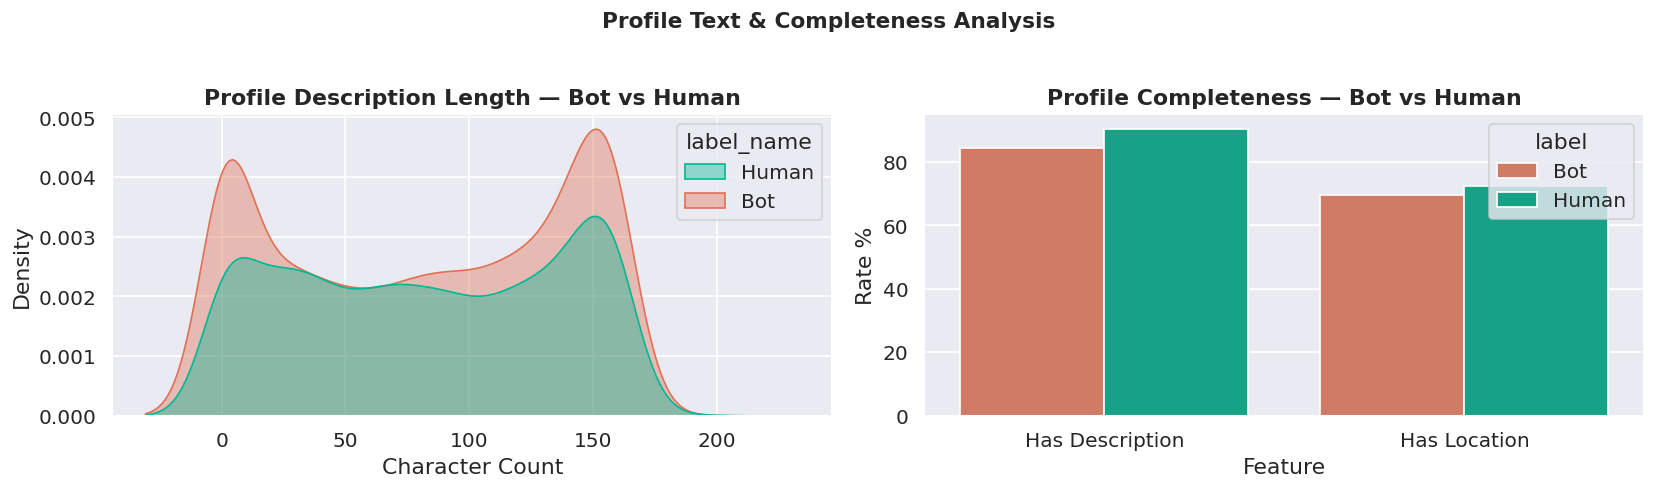

✅ Saved: profile_completeness.png


In [9]:
# ── Description length analysis ───────────────────────────────

train_df = train_df.withColumn(
    "desc_length",
    F.when(F.col("description").isNull(), 0).otherwise(F.length("description"))
)
train_df = train_df.withColumn(
    "has_description",
    F.when(F.col("description").isNull() | (F.trim(F.col("description")) == ''), 0).otherwise(1)
)
train_df = train_df.withColumn(
    "has_location",
    F.when(F.col("location").isNull() | (F.trim(F.col("location")) == '') |
           (F.lower(F.col("location")) == 'none'), 0).otherwise(1)
)

print("\n📝 Profile Description & Location Stats by Label:")
train_df.groupBy("label").agg(
    F.avg("desc_length").alias("avg_desc_length"),
    F.avg("has_description").alias("has_desc_rate"),
    F.avg("has_location").alias("has_loc_rate")
).orderBy("label").show()

# Visualize desc length
desc_pd = train_df.select("desc_length", "label").toPandas()
desc_pd['label_name'] = desc_pd['label'].astype(str).map({'1':'Bot','0':'Human'})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.kdeplot(data=desc_pd, x='desc_length', hue='label_name',
            fill=True, alpha=0.4,
            palette={'Bot': BOT_COLOR, 'Human': HUM_COLOR}, ax=axes[0])
axes[0].set_title("Profile Description Length — Bot vs Human", fontweight='bold')
axes[0].set_xlabel("Character Count")

# Has description / has location grouped bar
meta_records = []
for lbl, lname in [('1','Bot'), ('0','Human')]:
    sub = train_df.filter(F.col("label") == lbl)
    n   = sub.count()
    if n == 0: continue
    meta_records.append({
        'label': lname,
        'Has Description': sub.filter(F.col("has_description") == 1).count() / n * 100,
        'Has Location':    sub.filter(F.col("has_location")    == 1).count() / n * 100,
    })
meta_pd = pd.DataFrame(meta_records).melt(id_vars='label', var_name='Feature', value_name='Rate %')
sns.barplot(data=meta_pd, x='Feature', y='Rate %', hue='label',
            palette={'Bot': BOT_COLOR, 'Human': HUM_COLOR}, ax=axes[1])
axes[1].set_title("Profile Completeness — Bot vs Human", fontweight='bold')

plt.suptitle("Profile Text & Completeness Analysis",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("profile_completeness.png", bbox_inches='tight')
plt.show()
print("✅ Saved: profile_completeness.png")

---
## 5. Distributed Text Cleaning (Tweets) <a id='5'></a>

In [10]:
# ============================================================
# 📌 SECTION 5 — DISTRIBUTED TEXT CLEANING
# ============================================================
# Each account has a list of tweets (array<string>).
# We explode them into individual rows for text-level EDA.

def clean_tweet_text(text_col):
    """Chain of Spark regexp_replace for tweet cleaning."""
    t = F.lower(text_col)
    t = F.regexp_replace(t, r'http\S+|www\S+|https\S+', '')   # URLs
    t = F.regexp_replace(t, r'\@\w+',                   '')   # @mentions
    t = F.regexp_replace(t, r'\#',                      '')   # # symbol
    t = F.regexp_replace(t, r'[^a-z\s]',                '')   # non-alpha
    t = F.trim(t)
    return t

# ── Explode tweet array → one row per tweet ──────────────────
print("  ⚙️  Exploding tweet arrays...")
tweet_df = train_df.select(
    "id", "label",
    F.explode("tweet").alias("raw_tweet")
).filter(F.col("raw_tweet").isNotNull())

# ── RT flag before cleaning ──────────────────────────────────
tweet_df = tweet_df.withColumn(
    "is_rt", F.when(F.col("raw_tweet").startswith("RT "), 1).otherwise(0)
)

# ── Clean ────────────────────────────────────────────────────
print("  ⚙️  Cleaning tweet text...")
tweet_df = tweet_df.withColumn("clean_tweet", clean_tweet_text(F.col("raw_tweet")))
tweet_df = tweet_df.filter(F.length("clean_tweet") > 2)

# ── Tweet-level features ─────────────────────────────────────
tweet_df = tweet_df \
    .withColumn("tweet_len",  F.length("clean_tweet")) \
    .withColumn("word_count", F.size(F.split(F.col("clean_tweet"), " ")))

print("\n🔍 Cleaned Tweet Preview:")
tweet_df.select("label", "is_rt", "clean_tweet").show(5, truncate=80)
print(f"\n  ✅ Total tweet rows : {tweet_df.count():,}")

  ⚙️  Exploding tweet arrays...
  ⚙️  Cleaning tweet text...

🔍 Cleaned Tweet Preview:


+-----+-----+--------------------------------------------------------------------------------+
|label|is_rt|                                                                     clean_tweet|
+-----+-----+--------------------------------------------------------------------------------+
|    0|    1|rt   are you ready to see what our newest ships name will be  thanks to all o...|
|    0|    0|who has time for receipts not me  receipt scanners make it easy no mess  no s...|
|    0|    0|steady wants to encourage you to invest in your financial future connect your...|
|    0|    0|good one  but lets see if yall can do better than that come on everybody show...|
|    0|    0|                                                             lsunationalchamps\n|
+-----+-----+--------------------------------------------------------------------------------+
only showing top 5 rows




  ✅ Total tweet rows : 1,325,888


---
## 6. Tweet Count & Activity Analysis <a id='6'></a>


📊 Tweet Count Statistics (Full Train):


+-------+-------+-----------------+----------+
|min_len|max_len|          avg_len|median_len|
+-------+-------+-----------------+----------+
|      3|    397|89.11855677100931|        81|
+-------+-------+-----------------+----------+


📊 Tweet Length Stats by Label:


+-----+-----------------+------------------+
|label|    avg_tweet_len|    avg_word_count|
+-----+-----------------+------------------+
|    0|91.02234773741574|  17.4414588602985|
|    1|  87.525238293156|16.696489332224992|
+-----+-----------------+------------------+


🔁 Retweet Ratio by Label (Bot=1 / Human=0):


+-----+----------------------+-------------------+
|label|avg_tweets_per_account|       avg_rt_ratio|
+-----+----------------------+-------------------+
|    0|    168.78681195864766| 0.2625453438715948|
|    1|     156.3014291901256|0.38787703241795907|
+-----+----------------------+-------------------+



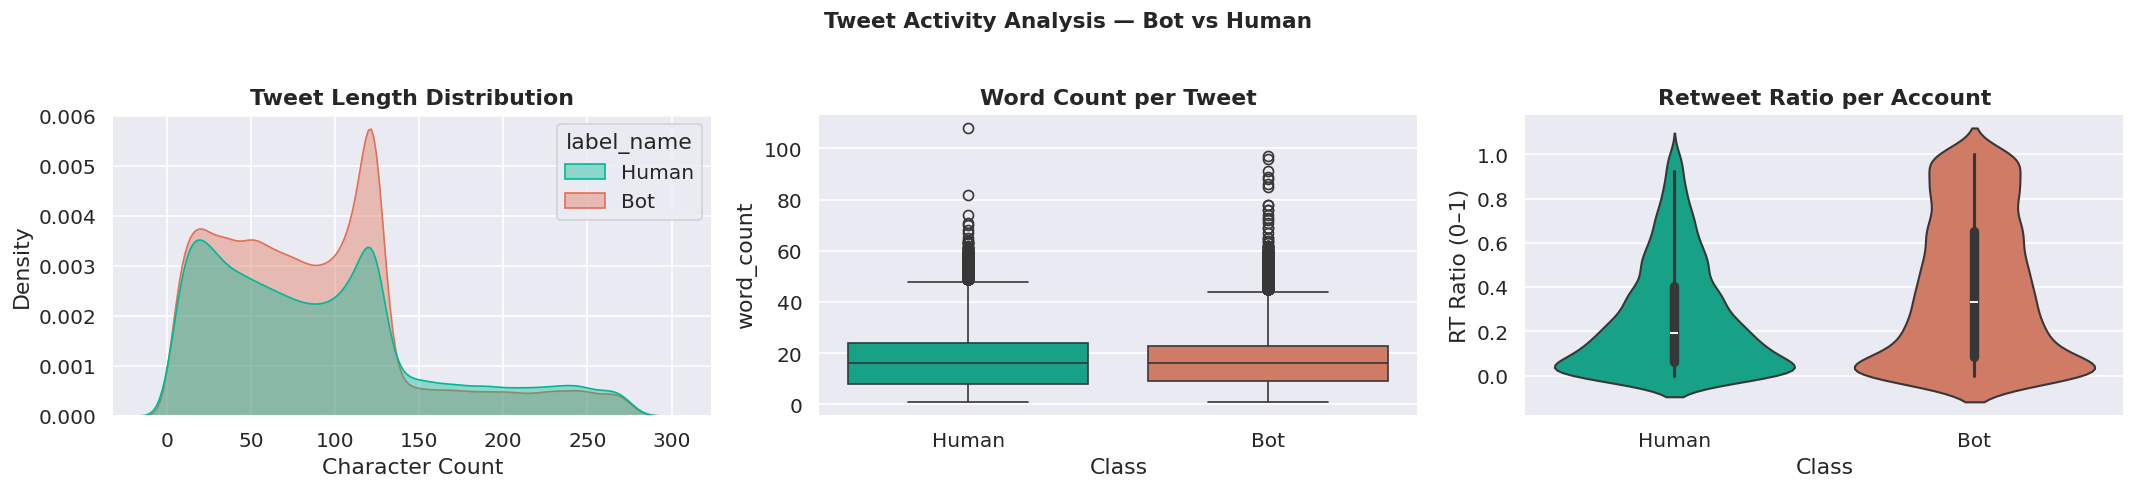

✅ Saved: tweet_activity.png


In [11]:
# ============================================================
# 📌 SECTION 6 — TWEET COUNT & ACTIVITY ANALYSIS
# ============================================================

# ── Tweets per account ───────────────────────────────────────
print("\n📊 Tweet Count Statistics (Full Train):")
tweet_df.select(
    F.min("tweet_len").alias("min_len"),
    F.max("tweet_len").alias("max_len"),
    F.avg("tweet_len").alias("avg_len"),
    F.expr("percentile_approx(tweet_len, 0.5)").alias("median_len")
).show()

print("\n📊 Tweet Length Stats by Label:")
tweet_df.groupBy("label").agg(
    F.avg("tweet_len").alias("avg_tweet_len"),
    F.avg("word_count").alias("avg_word_count")
).orderBy("label").show()

# ── Retweet ratio per account ────────────────────────────────
rt_stats = tweet_df.groupBy("id", "label").agg(
    F.count("*").alias("total_tweets"),
    F.sum("is_rt").alias("rt_count")
).withColumn(
    "rt_ratio",
    F.col("rt_count") / F.col("total_tweets")
)

print("\n🔁 Retweet Ratio by Label (Bot=1 / Human=0):")
rt_stats.groupBy("label").agg(
    F.avg("total_tweets").alias("avg_tweets_per_account"),
    F.avg("rt_ratio").alias("avg_rt_ratio")
).orderBy("label").show()

# ── Sample for plotting ──────────────────────────────────────
tl_sample = tweet_df.select("tweet_len", "word_count", "is_rt", "label") \
                    .sample(False, 0.2, seed=42).toPandas()
tl_sample['label_name'] = tl_sample['label'].astype(str).map({'1':'Bot','0':'Human'})

rt_pd = rt_stats.toPandas()
rt_pd['label_name'] = rt_pd['label'].astype(str).map({'1':'Bot','0':'Human'})

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
pal = {'Bot': BOT_COLOR, 'Human': HUM_COLOR}

# Tweet length KDE
sns.kdeplot(data=tl_sample, x='tweet_len', hue='label_name',
            fill=True, alpha=0.4, palette=pal, ax=axes[0])
axes[0].set_title("Tweet Length Distribution", fontweight='bold')
axes[0].set_xlabel("Character Count")

# Word count box plot
sns.boxplot(data=tl_sample, x='label_name', y='word_count',
            palette=pal, ax=axes[1])
axes[1].set_title("Word Count per Tweet", fontweight='bold')
axes[1].set_xlabel("Class")

# RT ratio
sns.violinplot(data=rt_pd, x='label_name', y='rt_ratio',
               palette=pal, inner='box', ax=axes[2])
axes[2].set_title("Retweet Ratio per Account", fontweight='bold')
axes[2].set_xlabel("Class")
axes[2].set_ylabel("RT Ratio (0–1)")

plt.suptitle("Tweet Activity Analysis — Bot vs Human",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("tweet_activity.png", bbox_inches='tight')
plt.show()
print("✅ Saved: tweet_activity.png")

---
## 7. Top Words & N-gram Analysis <a id='7'></a>

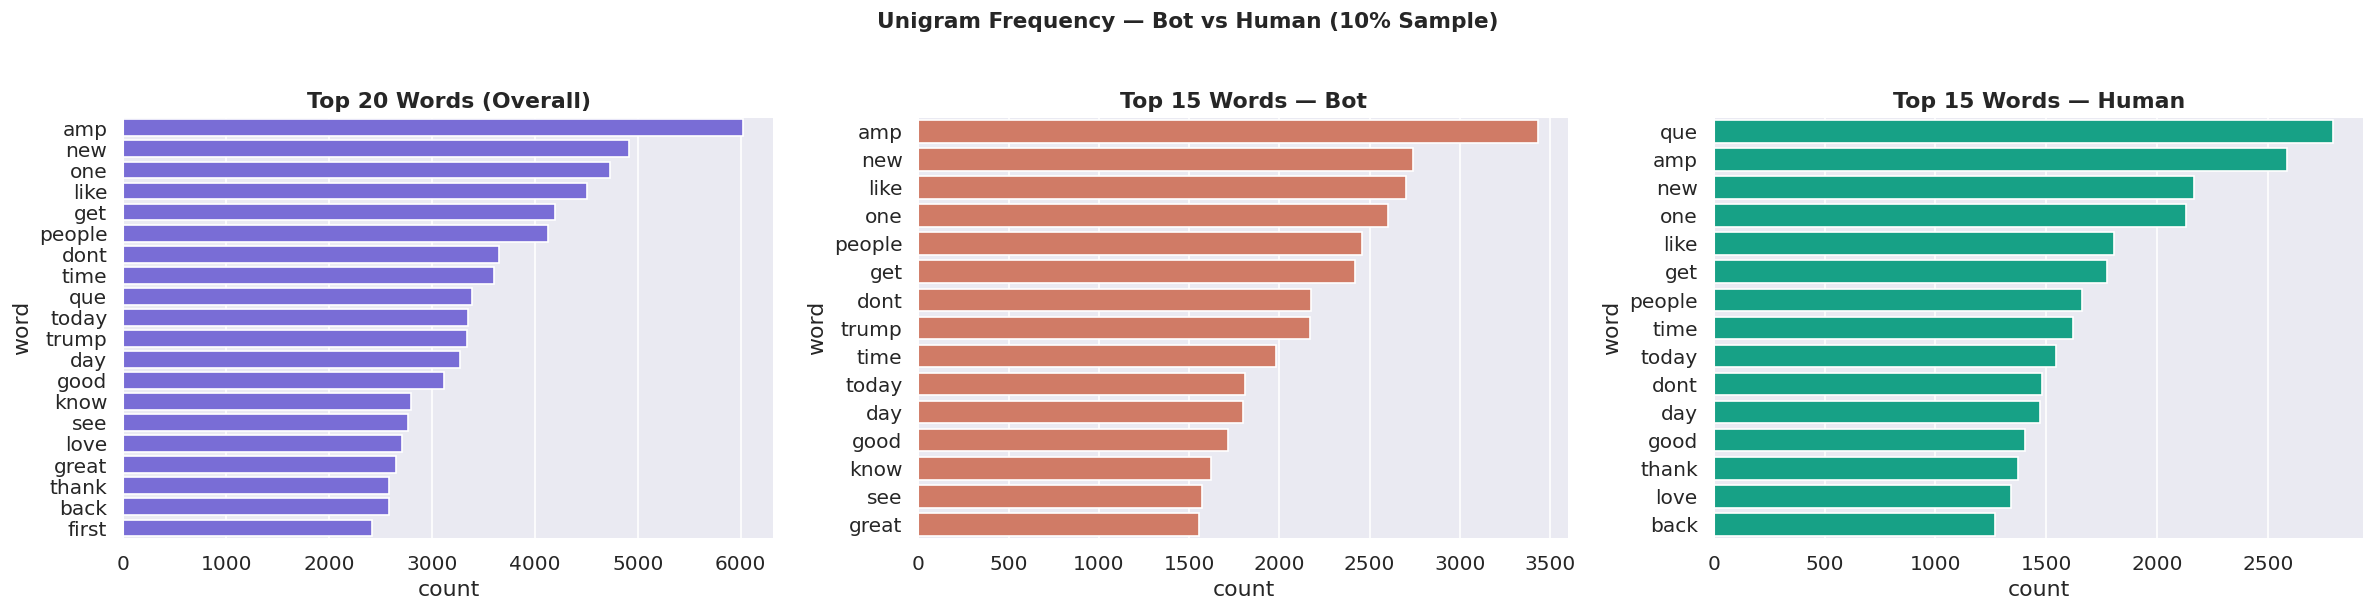

✅ Saved: top_words.png


In [12]:
# ============================================================
# 📌 SECTION 7 — TOP WORDS & N-GRAM FREQUENCY
# ============================================================

from pyspark.ml.feature import Tokenizer, StopWordsRemover, NGram

# ── Tokenize & remove stopwords ──────────────────────────────
tokenizer = Tokenizer(inputCol="clean_tweet", outputCol="tokens")
tokenized  = tokenizer.transform(tweet_df)

remover   = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
filtered  = remover.transform(tokenized)

# ── Unigram frequency on 10% sample ─────────────────────────
tok_sample = filtered.select("filtered_tokens", "label") \
                     .sample(False, 0.10, seed=42)

exploded = tok_sample.select(
    F.explode("filtered_tokens").alias("word"), "label"
).filter(F.length("word") > 2)

top_words = exploded.groupBy("word").count() \
                    .orderBy(F.desc("count")).limit(20).toPandas()

top_bot   = exploded.filter(F.col("label").isin('1', 1)) \
                    .groupBy("word").count() \
                    .orderBy(F.desc("count")).limit(15).toPandas()

top_hum   = exploded.filter(F.col("label").isin('0', 0)) \
                    .groupBy("word").count() \
                    .orderBy(F.desc("count")).limit(15).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=top_words, x='count', y='word', color=PALETTE[0], ax=axes[0])
axes[0].set_title("Top 20 Words (Overall)", fontweight='bold')

sns.barplot(data=top_bot, x='count', y='word', color=BOT_COLOR, ax=axes[1])
axes[1].set_title("Top 15 Words — Bot", fontweight='bold')

sns.barplot(data=top_hum, x='count', y='word', color=HUM_COLOR, ax=axes[2])
axes[2].set_title("Top 15 Words — Human", fontweight='bold')

plt.suptitle("Unigram Frequency — Bot vs Human (10% Sample)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("top_words.png", bbox_inches='tight')
plt.show()
print("✅ Saved: top_words.png")

Exception in thread "serve-DataFrame" java.net.SocketTimeoutException: Accept timed out
	at java.base/java.net.PlainSocketImpl.socketAccept(Native Method)
	at java.base/java.net.AbstractPlainSocketImpl.accept(AbstractPlainSocketImpl.java:474)
	at java.base/java.net.ServerSocket.implAccept(ServerSocket.java:565)
	at java.base/java.net.ServerSocket.accept(ServerSocket.java:533)
	at org.apache.spark.security.SocketAuthServer$$anon$1.run(SocketAuthServer.scala:65)


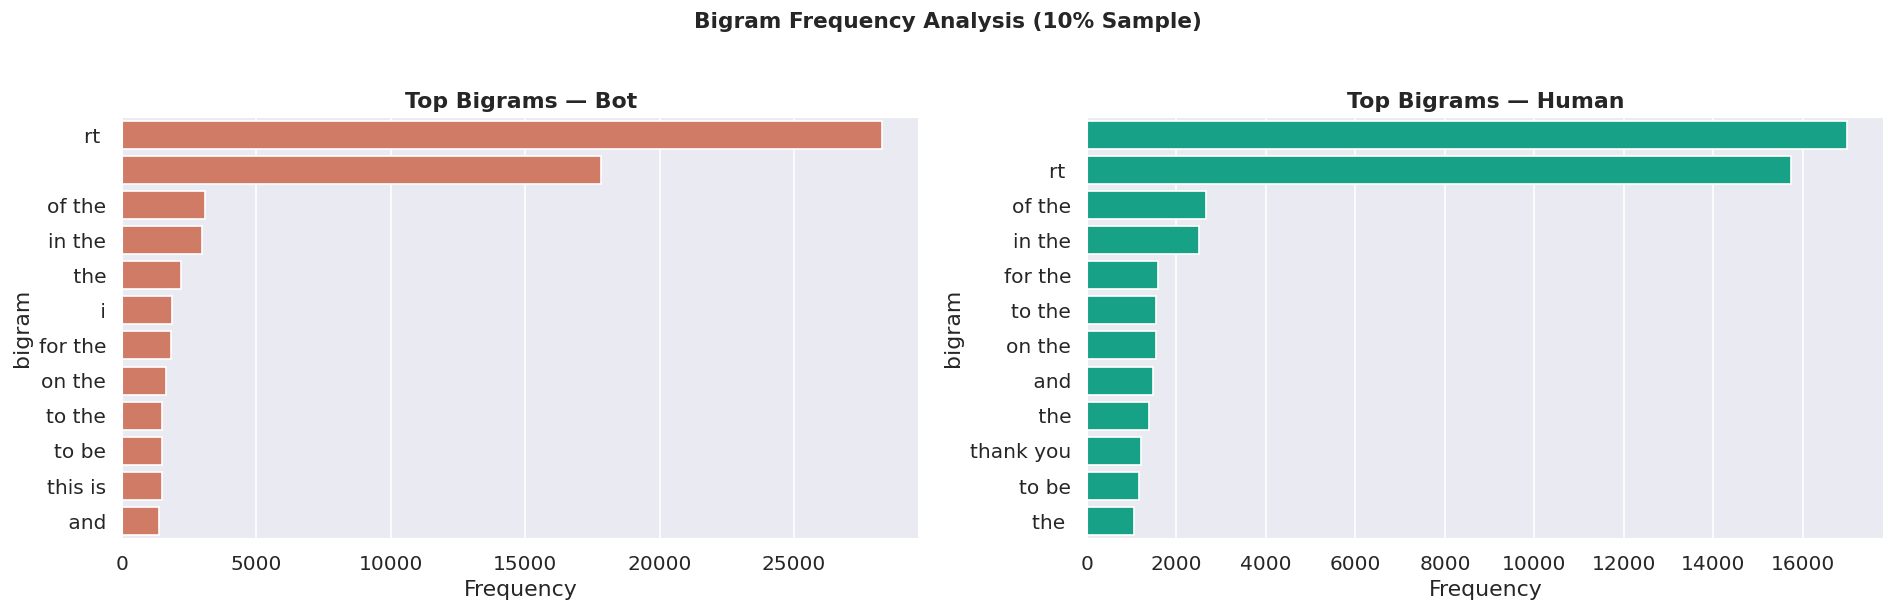

✅ Saved: bigram_analysis.png


In [16]:
# ── Bigram Analysis ───────────────────────────────────────────
# Use 'tokens' (pre-stopword-removal) so tweets retain
# enough words to form valid 2-word pairs.

bigram     = NGram(n=2, inputCol="tokens", outputCol="bigrams")
bigram_df  = bigram.transform(tokenized.sample(False, 0.10, seed=42))

bg_exploded = bigram_df.select(
    F.explode("bigrams").alias("bigram"), "label"
).filter(F.col("bigram").contains(" "))   # valid 2-word pairs only

top_bg_bot = bg_exploded.filter(F.col("label").isin('1', 1)) \
                        .groupBy("bigram").count() \
                        .orderBy(F.desc("count")).limit(12).toPandas()

top_bg_hum = bg_exploded.filter(F.col("label").isin('0', 0)) \
                        .groupBy("bigram").count() \
                        .orderBy(F.desc("count")).limit(12).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=top_bg_bot, x='count', y='bigram', color=BOT_COLOR, ax=axes[0])
axes[0].set_title("Top Bigrams — Bot",   fontweight='bold')
axes[0].set_xlabel("Frequency")

sns.barplot(data=top_bg_hum, x='count', y='bigram', color=HUM_COLOR, ax=axes[1])
axes[1].set_title("Top Bigrams — Human", fontweight='bold')
axes[1].set_xlabel("Frequency")

plt.suptitle("Bigram Frequency Analysis (10% Sample)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("bigram_analysis.png", bbox_inches='tight')
plt.show()
print("✅ Saved: bigram_analysis.png")


🌐 Top Domains Overall:


+-------------+-----+
|   domain_tag|count|
+-------------+-----+
|       Sports| 2725|
|Entertainment| 2674|
|     Business| 2535|
|     Politics| 2270|
+-------------+-----+



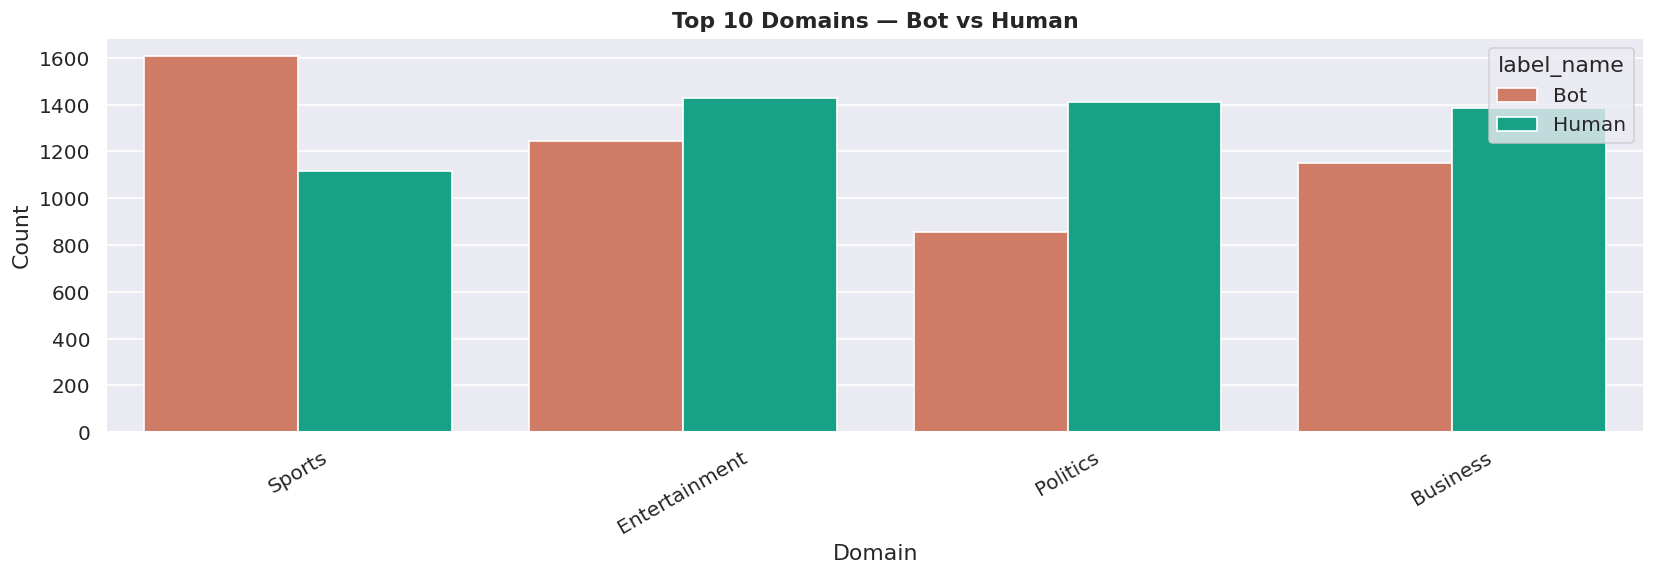

✅ Saved: domain_distribution.png


In [ ]:
# ── Domain Distribution ───────────────────────────────────────
# Each account has a list of domain tags (e.g., ['Politics','Sports'])

domain_df = train_df.select(
    "label", F.explode("domain").alias("domain_tag")
).filter(F.col("domain_tag").isNotNull())

print("\n🌐 Top Domains Overall:")
domain_df.groupBy("domain_tag").count() \
         .orderBy(F.desc("count")).show(15)

top_domains_pd = domain_df.groupBy("domain_tag", "label").count() \
                           .orderBy(F.desc("count")).toPandas()
top_domains_pd['label_name'] = top_domains_pd['label'].astype(str) \
                                                       .map({'1':'Bot','0':'Human'})

# Top 10 domains
top10 = top_domains_pd.groupby('domain_tag')['count'].sum() \
                      .nlargest(10).index
plot_dom = top_domains_pd[top_domains_pd['domain_tag'].isin(top10)]

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=plot_dom, x='domain_tag', y='count', hue='label_name',
            palette={'Bot': BOT_COLOR, 'Human': HUM_COLOR}, ax=ax)
ax.set_title("Top 10 Domains — Bot vs Human", fontweight='bold')
ax.set_xlabel("Domain")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig("domain_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: domain_distribution.png")

---
## 9. Class Balance & Stratified Sampling <a id='9'></a>


📉 Drawing Stratified Sample for Model Training...


  ✅ Sample Size : 4,193 accounts
  📊 Class Distribution:
label_name
Bot      2358
Human    1835
Name: count, dtype: int64

  ⚖️  Bot   ratio : 0.562
  ⚖️  Human ratio : 0.438


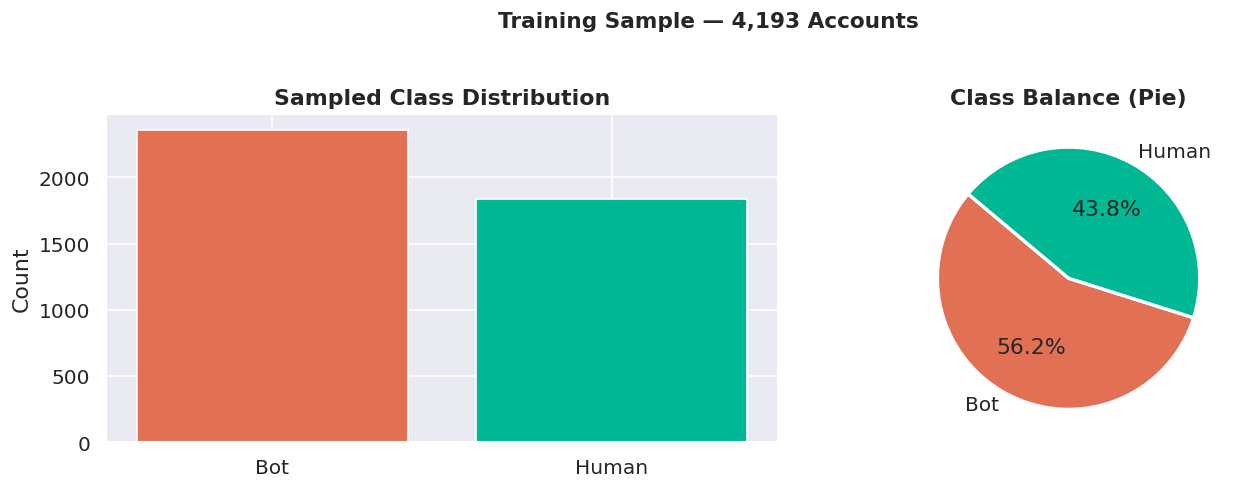

✅ Saved: sample_class_balance.png


In [14]:
# ============================================================
# 📌 SECTION 9 — CLASS BALANCE & STRATIFIED SAMPLING
# ============================================================

print("\n📉 Drawing Stratified Sample for Model Training...")
training_sample = train_df.sample(False, 0.5, seed=42).toPandas()

training_sample['label_name'] = training_sample['label'].astype(str) \
                                                         .map({'1':'Bot','0':'Human'})

print(f"  ✅ Sample Size : {len(training_sample):,} accounts")
vc = training_sample['label_name'].value_counts()
print(f"  📊 Class Distribution:\n{vc}")

bot_ratio = (training_sample['label'].astype(str) == '1').mean()
print(f"\n  ⚖️  Bot   ratio : {bot_ratio:.3f}")
print(f"  ⚖️  Human ratio : {1-bot_ratio:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pal = {'Bot': BOT_COLOR, 'Human': HUM_COLOR}

axes[0].bar(vc.index, vc.values,
            color=[BOT_COLOR if x=='Bot' else HUM_COLOR for x in vc.index],
            edgecolor='white')
axes[0].set_title("Sampled Class Distribution", fontweight='bold')
axes[0].set_ylabel("Count")

axes[1].pie(vc.values, labels=vc.index,
            colors=[BOT_COLOR if x=='Bot' else HUM_COLOR for x in vc.index],
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title("Class Balance (Pie)", fontweight='bold')

plt.suptitle(f"Training Sample — {len(training_sample):,} Accounts",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("sample_class_balance.png", bbox_inches='tight')
plt.show()
print("✅ Saved: sample_class_balance.png")